<a href="https://colab.research.google.com/github/pankaj201004/RL-ALL-EXPERIMENT/blob/main/rl_exp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Teach a Taxi to pick up and drop off passenger at the right locations with reinforcement learning

Implementing a simple grid-world environment and

training an agent using basic Q-learning

import dependencies


In [ ]:
import os
import gym
import numpy as np
print("pankaj yadav | roll no:61")

pankaj yadav | roll no:61


load environment


In [ ]:
env=gym.make("Taxi-v3", render_mode='rgb_array')
print("pankaj yadav | roll no:61")

pankaj yadav | roll no:61


In [ ]:
state=env.reset()
print("pankaj yadav | roll no:61")

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

pankaj yadav | roll no:61


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("pankaj yadav | roll no:61")
state

pankaj yadav | roll no:61


411

In [ ]:
print("pankaj yadav | roll no:61")
env.observation_space.n

pankaj yadav | roll no:61


500

In [ ]:
print("pankaj yadav | roll no:61")
env.action_space.n

pankaj yadav | roll no:61


6

pankaj yadav | roll no:61


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


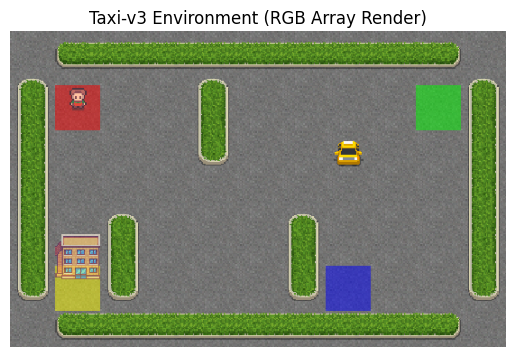

In [ ]:
print("pankaj yadav | roll no:61")
import matplotlib.pyplot as plt
# Create a new environment with render_mode='rgb_array'
env_rgb = gym.make("Taxi-v3", render_mode='rgb_array')
# Reset the environment to get an initial state
state_rgb = env_rgb.reset() # Modified this line to unpack only one value
# Capture the current frame as an RGB array
frame = env_rgb.render()
# Display the frame using matplotlib
plt.imshow(frame[0]) # Modified to access the array inside the list
plt.title("Taxi-v3 Environment (RGB Array Render)")
plt.axis('off') # Hide axes
plt.show()
# Close the environment
env_rgb.close()

In [ ]:
print("pankaj yadav | roll no:61")
env.observation_space.n

pankaj yadav | roll no:61


500

3.Possible Actions

down(0),up(1),right(2),left(3),pickup(4),drop-off(5)

In [ ]:
print("pankaj yadav | roll no:61")
n_states=env.observation_space.n
n_actions=env.action_space.n

pankaj yadav | roll no:61


In [ ]:
print("pankaj yadav | roll no:61")
n_actions

pankaj yadav | roll no:61


6

In [ ]:
print("pankaj yadav | roll no:61")
n_states

pankaj yadav | roll no:61


500

In [ ]:
print("pankaj yadav | roll no:61")
env.step(1)


pankaj yadav | roll no:61


(11,
 -1,
 False,
 {'prob': 1.0, 'action_mask': array([1, 0, 1, 0, 0, 0], dtype=int8)})

4.How good does behaving completely random do?

In [ ]:
print("pankaj yadav | roll no:61")
state=env.reset()
counter=0
g=0
reward=None

pankaj yadav | roll no:61


In [ ]:
print("pankaj yadav | roll no:61")
while reward !=20:
    state,reward,done,info=env.step(env.action_space.sample())
    counter+=1
    g+=reward

pankaj yadav | roll no:61


In [ ]:
print("pankaj yadav | roll no:61")
print("Solved in {} steps with a total reward of {}".format(counter,g))

pankaj yadav | roll no:61
Solved in 5825 steps with a total reward of -22562


In [ ]:
print("pankaj yadav | roll no:61")
Q=np.zeros([n_states,n_actions])

pankaj yadav | roll no:61


In [ ]:
print("pankaj yadav | roll no:61")
episodes=1
G=0
aplha=0.618

pankaj yadav | roll no:61


In [ ]:
print("pankaj yadav | roll no:61")
for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state = env.reset()
  finalState=state
  print("Inital State {}".format(state))
  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, done, info=env.step(action)
    Q[state, action] = Q[state, action] + aplha*(reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2

pankaj yadav | roll no:61
Inital State 331


In [ ]:
print("pankaj yadav | roll no:61")
G

pankaj yadav | roll no:61


-999

Lets run over multipe episode so that we can converge on an optimal policy

In [ ]:
print("pankaj yadav | roll no:61")
episodes = 2000
rewardTracker = []
G = 0
alpha = 0.618
for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state = env.reset()
  finalState=state
  print("Inital State {}".format(state))
  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, done, info=env.step(action)
    Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2
  if episode % 100 == 0:
    print('Episode {} Total Reward: {}'.format(episode,G))

pankaj yadav | roll no:61
Inital State 433
Inital State 32
Inital State 369
Inital State 221
Inital State 233
Inital State 26
Inital State 23
Inital State 249
Inital State 434
Inital State 486
Inital State 361
Inital State 133
Inital State 449
Inital State 353
Inital State 161
Inital State 301
Inital State 462
Inital State 133
Inital State 34
Inital State 332
Inital State 49
Inital State 421
Inital State 349
Inital State 208
Inital State 42
Inital State 352
Inital State 106
Inital State 346
Inital State 266
Inital State 84
Inital State 264
Inital State 48
Inital State 449
Inital State 414
Inital State 189
Inital State 94
Inital State 34
Inital State 104
Inital State 227
Inital State 163
Inital State 81
Inital State 363
Inital State 409
Inital State 313
Inital State 386
Inital State 109
Inital State 34
Inital State 466
Inital State 341
Inital State 203
Inital State 462
Inital State 349
Inital State 421
Inital State 381
Inital State 172
Inital State 151
Inital State 46
Inital State 491
I

In [ ]:
print("pankaj yadav | roll no:61")
G

pankaj yadav | roll no:61


8

WE OBSERVE THAT AFTER 2000 EPISODE THE EXPECTED CUMULATIVE REWARD IS HIGHER THAN ONE EPISODE WHICH IS HIGHER THAN RANDOM EPISODE